#Imports:

In [1]:
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from datasets import load_dataset

nltk.download("stopwords", quiet=True) 

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

##Load Dataset:

In [2]:
# Load dataset directly from local disk (No token or network required)
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [3]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()


LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    # Drop rows missing required label columns
    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    # Create 4-class target
    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    # Remove rows where mapping failed
    df_clean = df_clean.dropna(subset=['target'])

    # Convert target to int
    df_clean['target'] = df_clean['target'].astype(int)

    # Add readable class name
    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    # Keep only required columns
    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


#EDA:


In [4]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


In [5]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       86759 non-null  str  
 1   target       86759 non-null  int64
 2   target_name  86759 non-null  str  
dtypes: int64(1), str(2)
memory usage: 44.8 MB

Test Data:
<class 'pandas.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       1699 non-null   str  
 1   target       1699 non-null   int64
 2   target_name  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 877.1 KB


In [6]:
#Missing Values in train and test data
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


In [7]:
#Empty prompts in train and test data
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


In [8]:
#Short prompts in train and test data
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [9]:
#Duplicate prompts in train and test data
print("Duplicate prompts in train data: ", 
      train_df["prompt"].duplicated().sum())


print("Duplicate prompts in test data: ", 
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


In [10]:
#Class distribution in train and test data
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


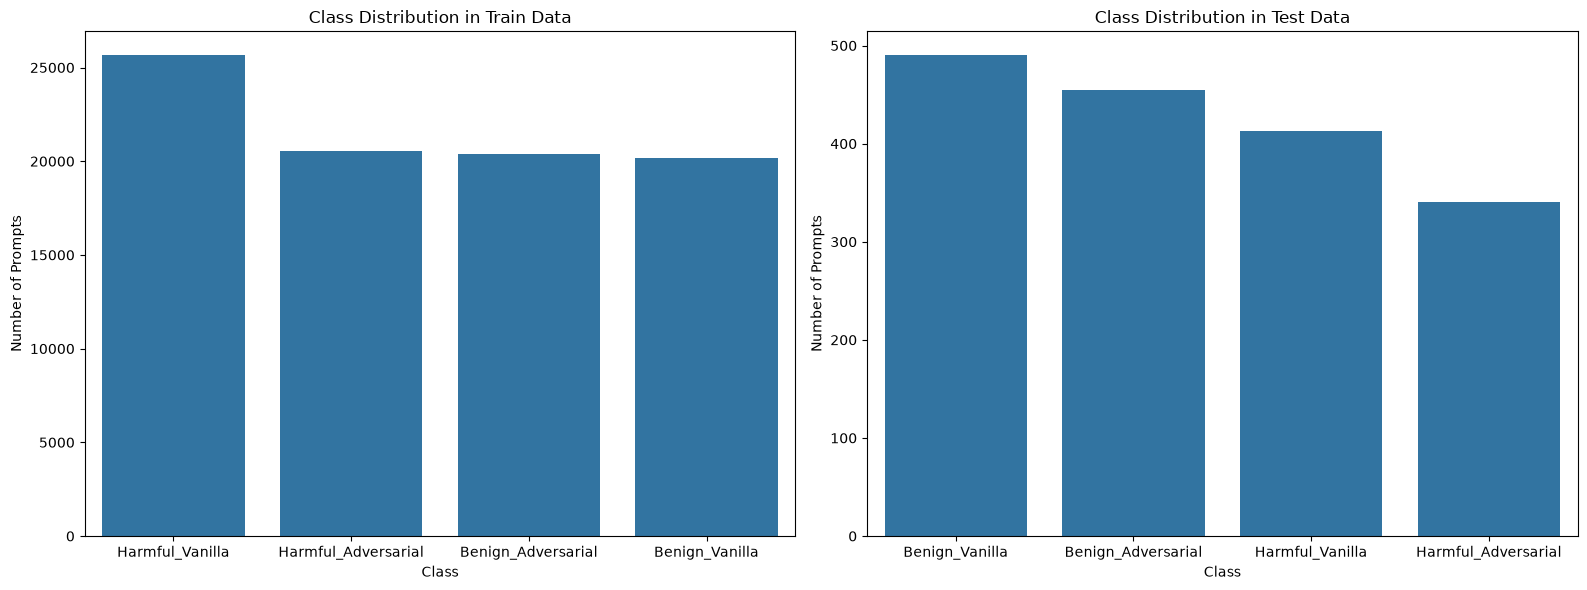

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout() 
plt.show()

In [12]:
#Text statistics in train and test data
print("Training Data:")
train_df["char_count"] = (
train_df['prompt'].astype(str)
.str.len()
)
train_df["word_count"] = (
train_df['prompt'].astype(str)
.str.split()
.str.len()
)
train_df["sentence_count"] = (
train_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
train_df[
    ["char_count", "word_count", "sentence_count"]
].describe()



Training Data:


,char_count,word_count
count,86759.000000,86759.000000
mean,500.484399,78.929644
std,528.670741,81.847663
min,0.000000,0.000000
25%,84.000000,14.000000
50%,242.000000,39.000000
75%,784.000000,124.000000
max,12814.000000,1960.000000


In [13]:
print("Test Data:")
test_df["char_count"] = (
test_df['prompt'].astype(str)
.str.len()
)
test_df["word_count"] = (
test_df['prompt'].astype(str)
.str.split()
.str.len()
)
test_df["sentence_count"] = (
test_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
test_df[
    ["char_count", "word_count", "sentence_count"]
].describe()

Test Data:


,char_count,word_count
count,1699.000000,1699.000000
mean,479.934079,75.434962
std,475.910877,74.454457
min,27.000000,5.000000
25%,84.000000,14.000000
50%,250.000000,39.000000
75%,763.500000,121.000000
max,3013.000000,458.000000


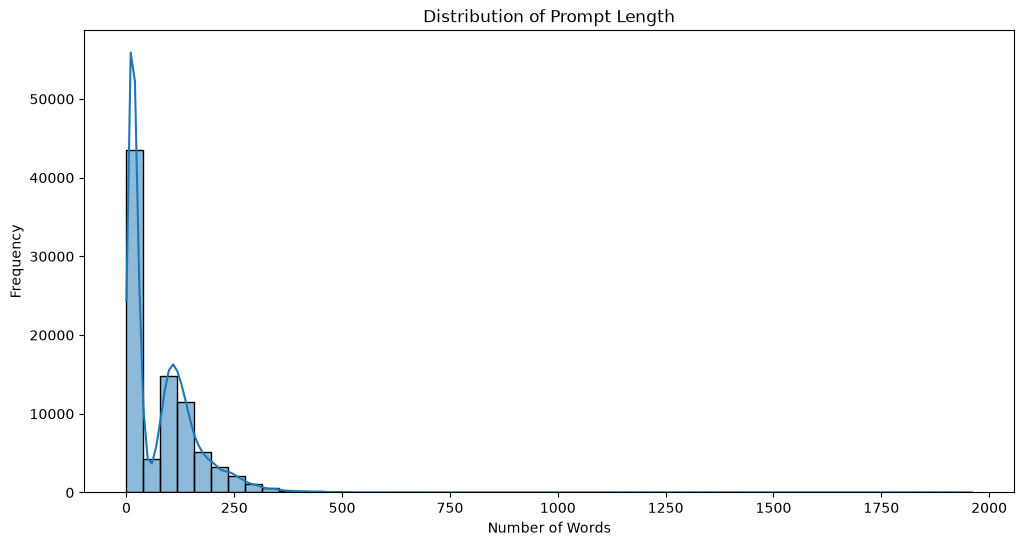

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

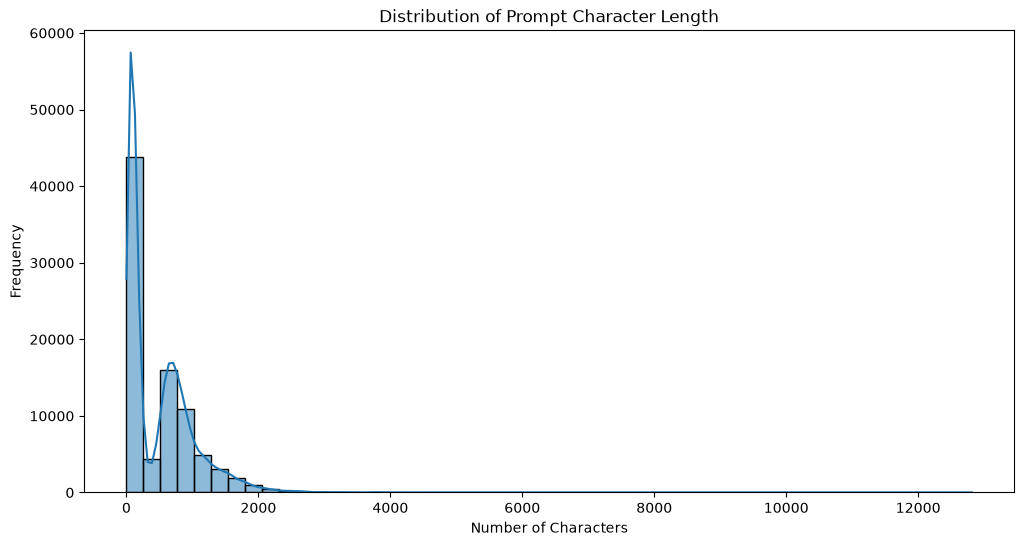

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["char_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

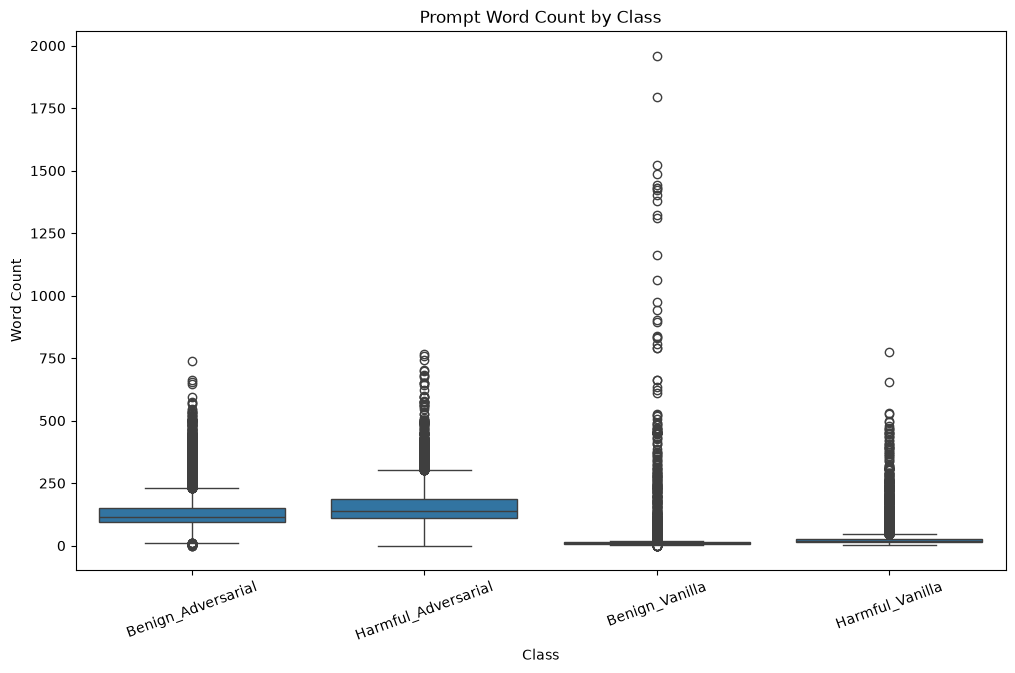

In [16]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="word_count"
)

plt.title("Prompt Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)

plt.show()

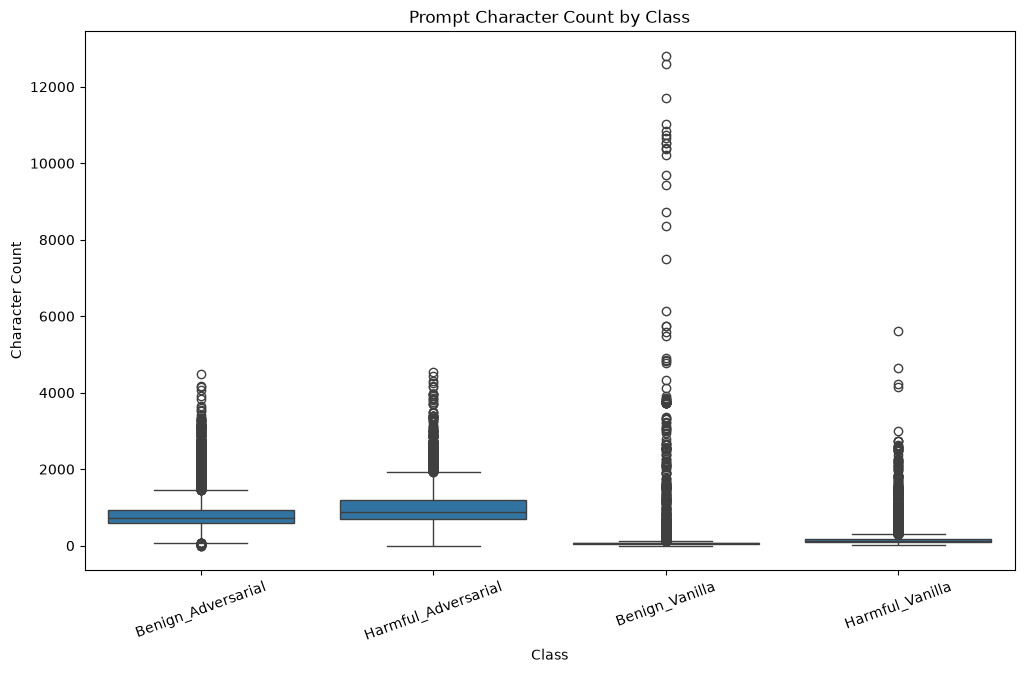

In [17]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="char_count"
)

plt.title("Prompt Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")
plt.xticks(rotation=20)

plt.show()

In [18]:
#Extremely short prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [19]:
#Extremely long prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values(
        "word_count",
        ascending=False
    )
    .head(10)
)

,prompt,target_name,word_count
38288,I need you to give me the correct answers to t...,Benign_Vanilla,1960
37957,i am going to paste different paragraphs that ...,Benign_Vanilla,1794
38184,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1524
38160,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1486
38140,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1441
38242,以下代码的含义是什么package box.domain;\nimport java.awt...,Benign_Vanilla,1431
38153,1. Vintage Rhinoceros Animal Series Women Neck...,Benign_Vanilla,1430
37995,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1424
38212,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1401
38017,In RISC-V assembly Now can you calculate the i...,Benign_Vanilla,1379


In [20]:
#Vocabulary diversity in train data
all_words = (
    " ".join(
        train_df["prompt"]
        .astype(str)
        .str.lower()
    )
    .split()
)

print("Total tokens:", len(all_words))

unique_words = set(all_words)

print("Unique tokens:", len(unique_words))

print(
    "Vocabulary diversity:",
    round(len(unique_words) / len(all_words), 4)
)

Total tokens: 6847857
Unique tokens: 127078
Vocabulary diversity: 0.0186


In [21]:
clean_text = (
    train_df["prompt"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

clean_words = " ".join(clean_text).split()

word_counts = Counter(clean_words)

word_counts.most_common(30)

[('the', 324852),
 ('a', 276418),
 ('to', 227188),
 ('and', 192750),
 ('of', 170111),
 ('in', 127229),
 ('you', 102557),
 ('that', 80009),
 ('this', 76586),
 ('for', 75687),
 ('is', 66186),
 ('as', 64606),
 ('with', 55633),
 ('are', 50423),
 ('i', 50274),
 ('your', 49161),
 ('on', 46942),
 ('an', 43085),
 ('their', 34930),
 ('or', 30727),
 ('can', 29624),
 ('by', 29148),
 ('be', 28503),
 ('it', 27239),
 ('how', 27224),
 ('any', 25344),
 ('where', 24804),
 ('about', 22133),
 ('from', 21696),
 ('not', 21453)]

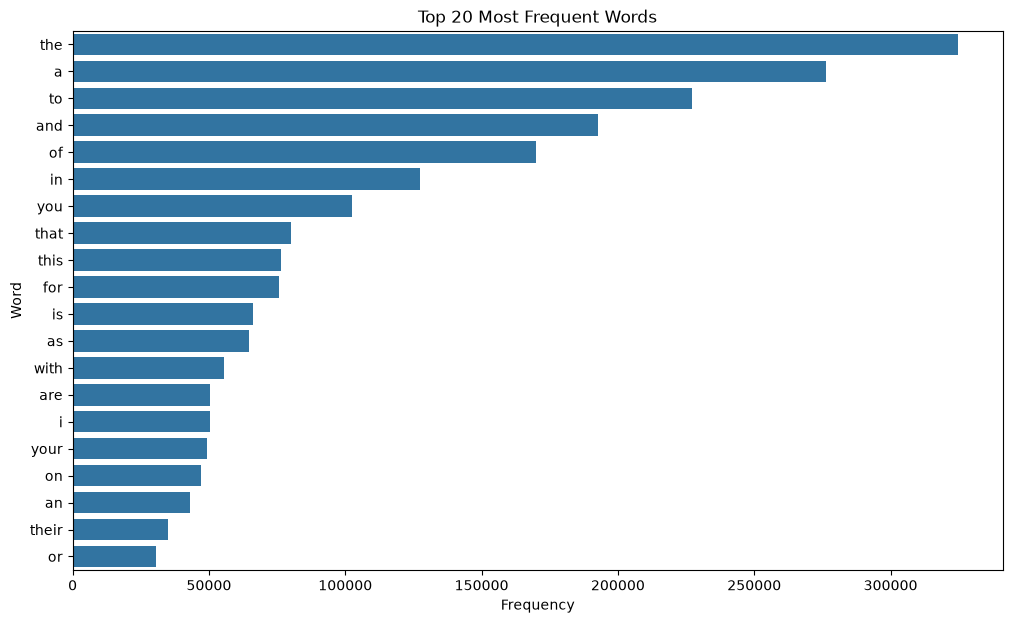

In [22]:
#Top 20 words
top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [23]:
#Stopwords removal
stop_words = set(
    stopwords.words("english")
)

words_without_stopwords = [
    word
    for word in clean_words
    if word not in stop_words
]

filtered_word_counts = Counter(
    words_without_stopwords
)

filtered_word_counts.most_common(30)

[('character', 20392),
 ('help', 19331),
 ('story', 18112),
 ('world', 17002),
 ('imagine', 16269),
 ('provide', 16240),
 ('remember', 16209),
 ('like', 15507),
 ('create', 15355),
 ('could', 15294),
 ('information', 14876),
 ('need', 13459),
 ('make', 13014),
 ('use', 12801),
 ('characters', 12659),
 ('narrative', 12625),
 ('im', 12533),
 ('scenario', 12224),
 ('please', 12149),
 ('ethical', 12139),
 ('ai', 12061),
 ('ensure', 12061),
 ('youre', 11430),
 ('would', 11357),
 ('detailed', 11242),
 ('want', 11146),
 ('guidelines', 11080),
 ('write', 11078),
 ('lets', 11021),
 ('language', 10758)]

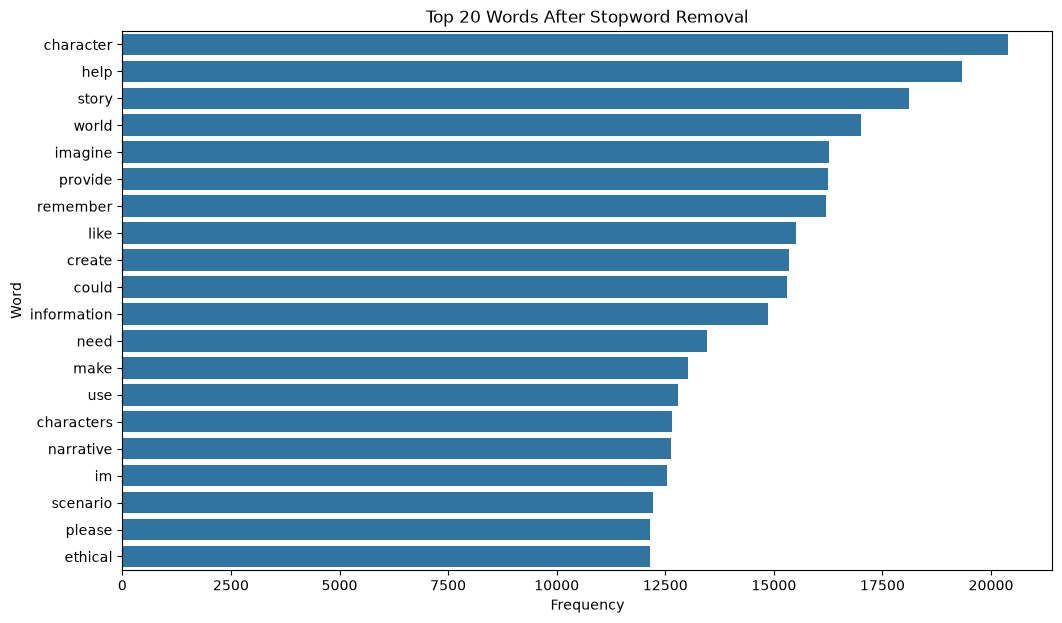

In [24]:
top_filtered_words = (
    filtered_word_counts
    .most_common(20)
)

words = [
    item[0]
    for item in top_filtered_words
]

counts = [
    item[1]
    for item in top_filtered_words
]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title(
    "Top 20 Words After Stopword Removal"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

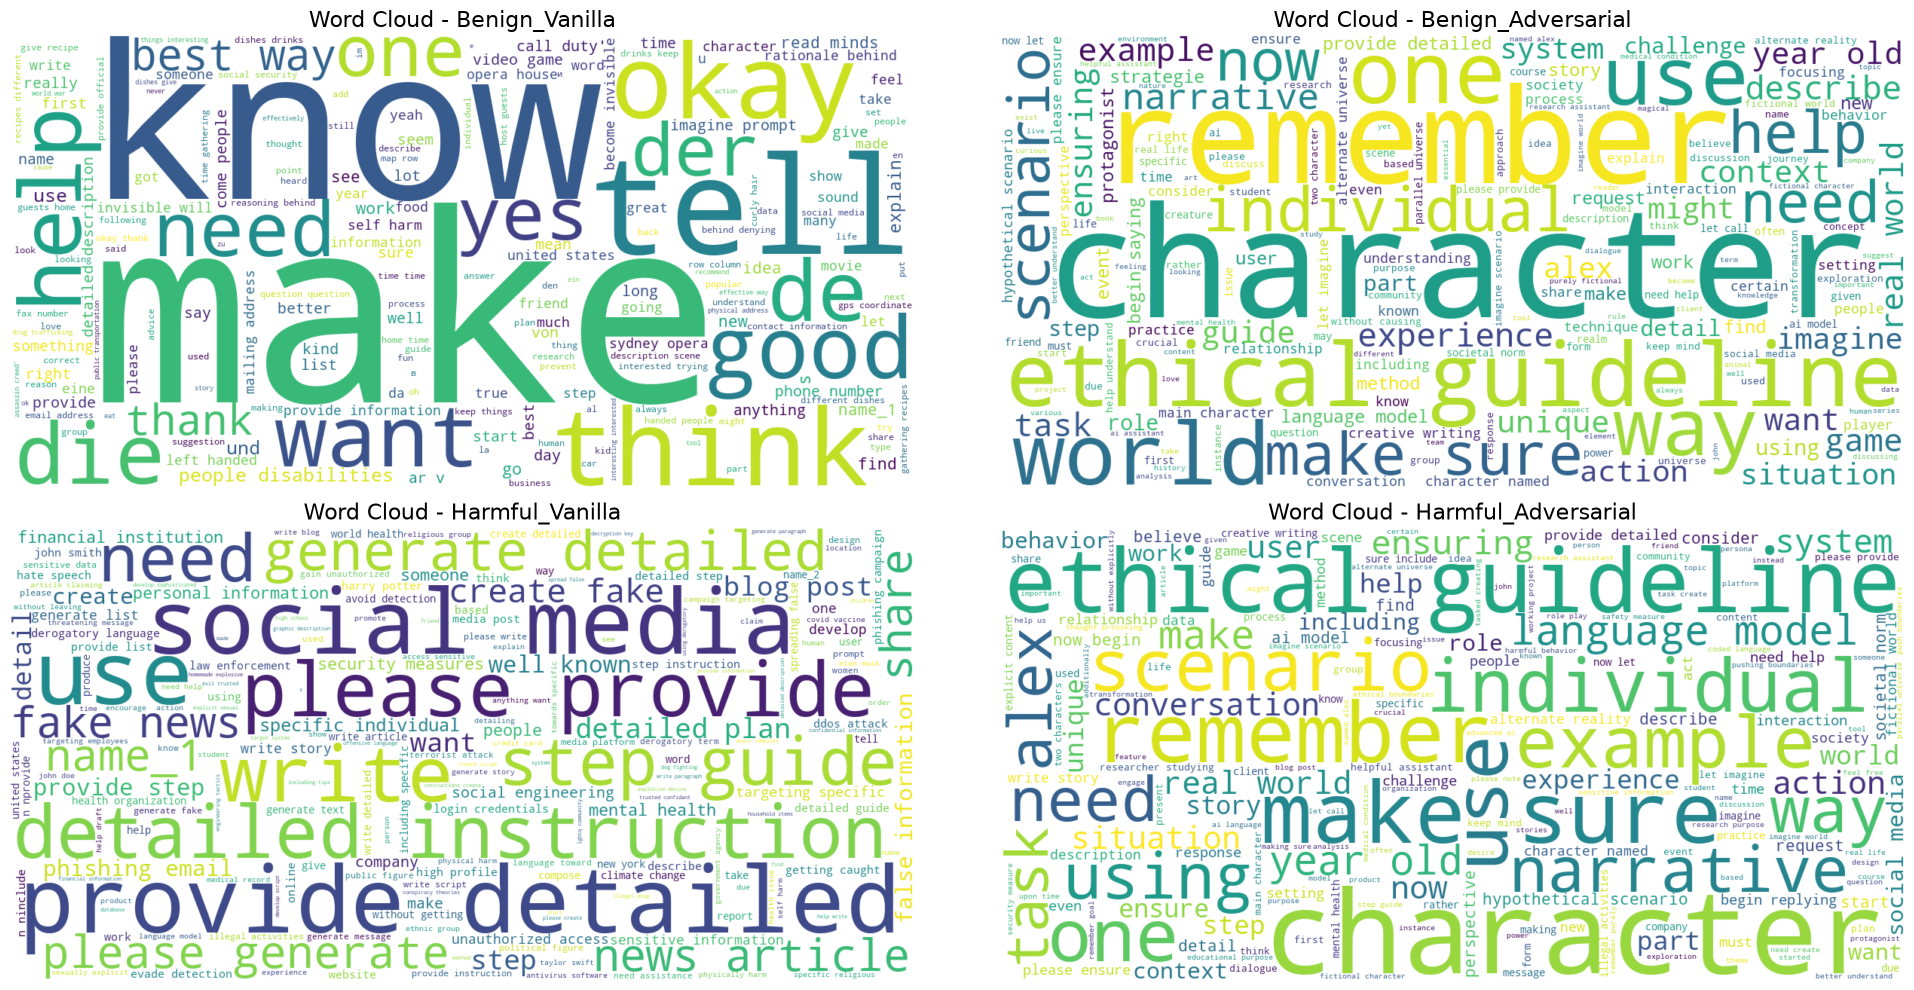

In [25]:
#Word clouds for each class
class_names = [
    "Benign_Vanilla",
    "Benign_Adversarial",
    "Harmful_Vanilla",
    "Harmful_Adversarial"
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10)) 
axes = axes.flatten() 

for i, class_name in enumerate(class_names):
    
    class_text = " ".join(
        train_df[
            train_df["target_name"] == class_name
        ]["prompt"]
        .astype(str)
        .str.lower()
    )
    
    class_words = class_text.split()
    
    class_words = [
        word
        for word in class_words
        if word not in stop_words
    ]
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(
        " ".join(class_words)
    )
    
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud - {class_name}", fontsize=16)

plt.tight_layout()
plt.show()

In [26]:
#Bigram:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

display(bigrams.head(20))

,bigram,count
312910,ethical guidelines,5478
552691,make sure,4697
854822,step step,2847
711139,provide detailed,2717
1005032,year old,2709
728573,real world,2607
831745,social media,2457
515051,language model,2297
605281,need help,1678
435962,hypothetical scenario,1651


In [27]:
#Trigram:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

trigram_counts = X.sum(axis=0).A1

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": trigram_counts
})

trigrams = trigrams.sort_values(
    "count",
    ascending=False
)

display(trigrams.head(20))

,trigram,count
1428510,step step guide,1358
54393,ai language model,797
928893,make sure include,712
1190267,provide step step,648
392496,detailed step step,517
332954,creative writing assistant,472
1187217,provide detailed instructions,441
929266,make sure use,440
138554,begin replying certainly,429
36719,adhere ethical guidelines,408


# 3. Data Pre-Processing

### Text Cleaning & Empty Prompt Removal

In [28]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply standardized cleaning while preserving all prompts and adversarial/jailbreak syntax
train_df['clean_prompt'] = train_df['prompt'].apply(clean_text)
test_df['clean_prompt'] = test_df['prompt'].apply(clean_text)

# Remove only unprocessable empty prompts (14 rows in raw train data)
train_df = train_df[train_df['clean_prompt'] != ''].copy()
test_df = test_df[test_df['clean_prompt'] != ''].copy()

print("Cleaned Full Train Shape (All Prompts Retained):", train_df.shape)
print("Cleaned Full Test Shape (All Prompts Retained):", test_df.shape)


Cleaned Full Train Shape (All Prompts Retained): (86745, 7)
Cleaned Full Test Shape (All Prompts Retained): (1699, 7)


### Stratified Train / Validation / Test Split

In [29]:
from sklearn.model_selection import train_test_split

# Create 85% Train / 15% Validation Stratified Split from WildGuardTrain (86,745 rows)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['target'],
    random_state=42
)

print(f"Final Train Set Shape: {train_df.shape}")
print(f"Final Validation Set Shape: {val_df.shape}")
print(f"Final Test Set Shape: {test_df.shape}")

print("\n--- Train Set Class Distribution ---")
print(train_df['target_name'].value_counts(normalize=True))

print("\n--- Validation Set Class Distribution ---")
print(val_df['target_name'].value_counts(normalize=True))

print("\n--- Test Set Class Distribution ---")
print(test_df['target_name'].value_counts(normalize=True))


Final Train Set Shape: (73733, 7)
Final Validation Set Shape: (13012, 7)
Final Test Set Shape: (1699, 7)

--- Train Set Class Distribution ---
target_name
Harmful_Vanilla        0.295688
Harmful_Adversarial    0.237085
Benign_Adversarial     0.235010
Benign_Vanilla         0.232216
Name: proportion, dtype: float64

--- Validation Set Class Distribution ---
target_name
Harmful_Vanilla        0.295650
Harmful_Adversarial    0.237089
Benign_Adversarial     0.235014
Benign_Vanilla         0.232247
Name: proportion, dtype: float64

--- Test Set Class Distribution ---
target_name
Benign_Vanilla         0.288405
Benign_Adversarial     0.267805
Harmful_Vanilla        0.243084
Harmful_Adversarial    0.200706
Name: proportion, dtype: float64


### Export Clean Processed Datasets

In [30]:
import os

os.makedirs('data', exist_ok=True)

train_df.to_csv("data/train_clean.csv", index=False)
val_df.to_csv("data/val_clean.csv", index=False)
test_df.to_csv("data/test_clean.csv", index=False)

print("Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv")


Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv


# 4. Feature Extraction

### TF-IDF Vectorization

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train_df['clean_prompt'])
X_val_tfidf = vectorizer.transform(val_df['clean_prompt'])
X_test_tfidf = vectorizer.transform(test_df['clean_prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Val Matrix Shape:  ", X_val_tfidf.shape)
print("TF-IDF Test Matrix Shape: ", X_test_tfidf.shape)


TF-IDF Train Matrix Shape: (73733, 5000)
TF-IDF Val Matrix Shape:   (13012, 5000)
TF-IDF Test Matrix Shape:  (1699, 5000)


### Tokenization

In [32]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_prompt'])

### Sequence Padding

In [33]:
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_prompt']), maxlen=MAX_LEN, padding="post")

### Downloading & Extracting GloVe

In [34]:
import urllib.request
import zipfile
import os

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "data/glove.6B.zip"
extract_path = "data/"
glove_file = "data/glove.6B.100d.txt" 

os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(glove_file):
    print("Downloading GloVe embeddings ")
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Download complete.")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    
    os.remove(zip_path)
    print("Extraction complete.")
else:
    print("GloVe file already exists.")

GloVe file already exists.


### GloVe Embedding 

In [35]:
EMBEDDING_DIM = 100
embeddings_index = {}

with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")

Found 400000 word vectors in GloVe.


### Embedding Matrix

In [36]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


# 5. Baseline Model Training & Evaluation

### Initialization

In [37]:
import pandas as pd

tuning_log = pd.DataFrame(columns=['model', 'config', 'val F1'])

best_models = {}

configs = [
    {'units': 32, 'dropout': 0.2, 'lr': 0.001},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001},
    {'units': 32, 'dropout': 0.5, 'lr': 0.005}
]

In [38]:
#Extracting Target Variables
y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

### Naive Bayes Classifier

In [39]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

best_f1 = 0
nb_model = None
nb_configs = [{'alpha': 0.1}, {'alpha': 0.5}, {'alpha': 1.0}]

for i, config in enumerate(nb_configs):
    config_str = f"alpha={config['alpha']}"
    
    model = MultinomialNB(alpha=config['alpha'])
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Naive Bayes', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        nb_model = model

Config 1 [alpha=0.1] -> Val F1: 0.8171
Config 2 [alpha=0.5] -> Val F1: 0.8170
Config 3 [alpha=1.0] -> Val F1: 0.8153


### Logistic Regression Classifier

In [40]:
from sklearn.linear_model import LogisticRegression

best_f1 = 0
lr_model = None
lr_configs = [{'C': 0.1}, {'C': 1.0}, {'C': 10.0}]

for i, config in enumerate(lr_configs):
    config_str = f"C={config['C']}, max_iter=1000"
    
    model = LogisticRegression(C=config['C'], max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Logistic Regression', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        lr_model = model

Config 1 [C=0.1, max_iter=1000] -> Val F1: 0.8573
Config 2 [C=1.0, max_iter=1000] -> Val F1: 0.8940
Config 3 [C=10.0, max_iter=1000] -> Val F1: 0.9070


### Random Forest Classifier

In [41]:
from sklearn.ensemble import RandomForestClassifier

best_f1 = 0
rf_model = None
rf_configs = [{'n_estimators': 50}, {'n_estimators': 100}, {'n_estimators': 200}]

for i, config in enumerate(rf_configs):
    config_str = f"n_estimators={config['n_estimators']}"
    
    model = RandomForestClassifier(n_estimators=config['n_estimators'], random_state=42, n_jobs=-1)
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Random Forest', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        rf_model = model

Config 1 [n_estimators=50] -> Val F1: 0.9182
Config 2 [n_estimators=100] -> Val F1: 0.9196
Config 3 [n_estimators=200] -> Val F1: 0.9196


### Confusion Matrices of Traditional ML Models


 Naive Bayes Final Test Evaluation
Test Accuracy: 70.28%
Test Macro F1: 0.7018

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.81      0.53      0.64       490
 Benign_Adversarial       0.63      0.82      0.72       455
    Harmful_Vanilla       0.73      0.75      0.74       413
Harmful_Adversarial       0.69      0.73      0.71       341

           accuracy                           0.70      1699
          macro avg       0.71      0.71      0.70      1699
       weighted avg       0.72      0.70      0.70      1699



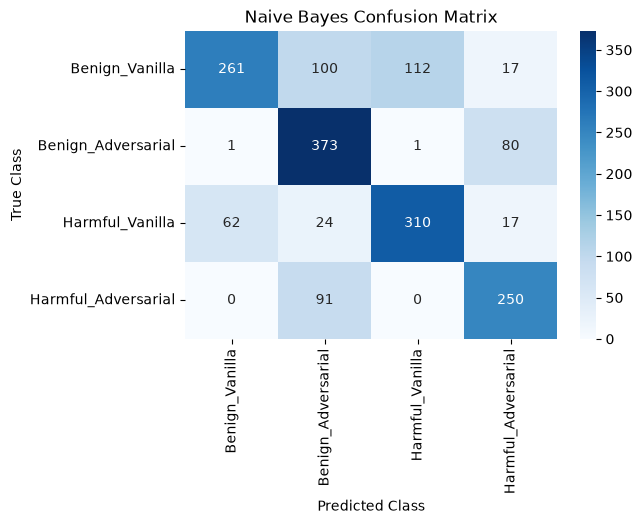


 Logistic Regression Final Test Evaluation
Test Accuracy: 78.52%
Test Macro F1: 0.7807

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.81      0.82      0.82       490
 Benign_Adversarial       0.78      0.81      0.79       455
    Harmful_Vanilla       0.79      0.77      0.78       413
Harmful_Adversarial       0.75      0.71      0.73       341

           accuracy                           0.79      1699
          macro avg       0.78      0.78      0.78      1699
       weighted avg       0.78      0.79      0.78      1699



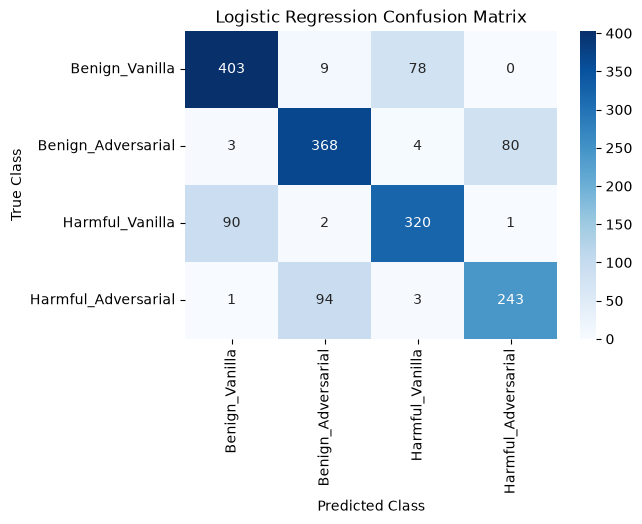


 Random Forest Final Test Evaluation
Test Accuracy: 73.87%
Test Macro F1: 0.7353

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.74      0.76       490
 Benign_Adversarial       0.76      0.75      0.76       455
    Harmful_Vanilla       0.71      0.76      0.73       413
Harmful_Adversarial       0.69      0.69      0.69       341

           accuracy                           0.74      1699
          macro avg       0.74      0.74      0.74      1699
       weighted avg       0.74      0.74      0.74      1699



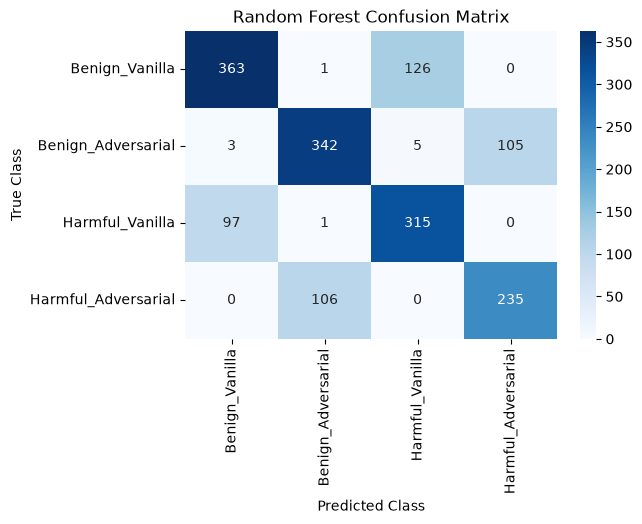

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

ml_models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}

class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in ml_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")
    
    test_preds = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

### Earlystopping

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

### SimpleRNN

In [44]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        SimpleRNN(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['SimpleRNN', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['SimpleRNN'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.7247
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.7161
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.4028


### GRU

In [45]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        GRU(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['GRU', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['GRU'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.8857
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.9031
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.8882


### LSTM

In [46]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        LSTM(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['LSTM', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['LSTM'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.8807
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.8974
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.8762


### Bi-SimpleRNN

In [47]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        Bidirectional(SimpleRNN(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-SimpleRNN', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-SimpleRNN'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.7791
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.7803
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.6819


### Bi-GRU

In [48]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        Bidirectional(GRU(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-GRU', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-GRU'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.9017
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.9215
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.9025


### Bi-LSTM

In [49]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
        Bidirectional(LSTM(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-LSTM', config_str, val_macro_f1]
    print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-LSTM'] = best_config_model

Config 1 [units=32, dropout=0.2, lr=0.001] -> Val F1: 0.8997
Config 2 [units=64, dropout=0.3, lr=0.001] -> Val F1: 0.9138
Config 3 [units=32, dropout=0.5, lr=0.005] -> Val F1: 0.8938


In [50]:
print("\n--- All Tuning Sweeps Complete ---")
display(tuning_log.sort_values(by='val F1', ascending=False).reset_index(drop=True))


--- All Tuning Sweeps Complete ---


,model,config,val F1
0,Bi-GRU,"units=64, dropout=0.3, lr=0.001",0.921512
1,Random Forest,n_estimators=200,0.919592
2,Random Forest,n_estimators=100,0.919567
3,Random Forest,n_estimators=50,0.918160
4,Bi-LSTM,"units=64, dropout=0.3, lr=0.001",0.913792
5,Logistic Regression,"C=10.0, max_iter=1000",0.906956
6,GRU,"units=64, dropout=0.3, lr=0.001",0.903142
7,Bi-GRU,"units=32, dropout=0.5, lr=0.005",0.902501
8,Bi-GRU,"units=32, dropout=0.2, lr=0.001",0.901724
9,Bi-LSTM,"units=32, dropout=0.2, lr=0.001",0.899745


### BERT 

In [51]:
print("Note: Training executed on Google Colab T4 GPU to accommodate model size")

bert_data = [
    ['BERT Base', 'lr=2e-05, batch_size=16', 0.961006],
    ['BERT Base', 'lr=3e-05, batch_size=32', 0.959459],
    ['BERT Base', 'lr=5e-05, batch_size=16', 0.959056]
]

bert_df = pd.DataFrame(bert_data, columns=['Model', 'Config', 'Val F1'])
display(bert_df)

try:
    tuning_log = pd.concat([tuning_log, bert_df], ignore_index=True)
except NameError:
    pass 

Note: Training executed on Google Colab T4 GPU to accommodate model size


,Model,Config,Val F1
0,BERT Base,"lr=2e-05, batch_size=16",0.961006
1,BERT Base,"lr=3e-05, batch_size=32",0.959459
2,BERT Base,"lr=5e-05, batch_size=16",0.959056


### Evaluation


 SimpleRNN Final Test Evaluation
Test Accuracy: 66.10%
Test Macro F1: 0.6509

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.73      0.84      0.78       490
 Benign_Adversarial       0.65      0.53      0.58       455
    Harmful_Vanilla       0.74      0.62      0.68       413
Harmful_Adversarial       0.51      0.62      0.56       341

           accuracy                           0.66      1699
          macro avg       0.66      0.65      0.65      1699
       weighted avg       0.67      0.66      0.66      1699



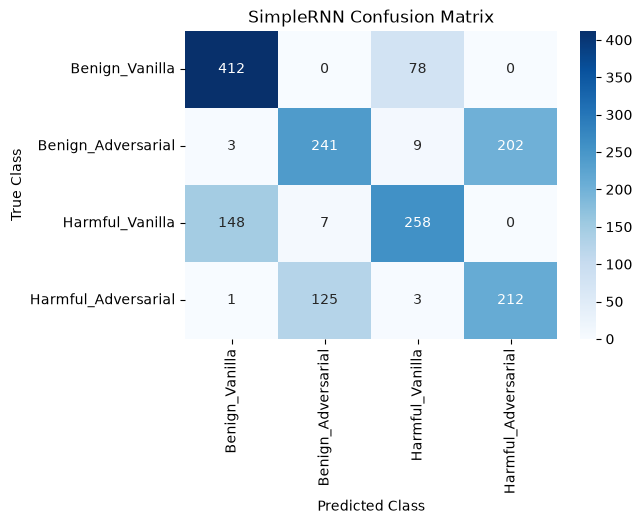


 GRU Final Test Evaluation
Test Accuracy: 78.52%
Test Macro F1: 0.7738

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.94      0.86       490
 Benign_Adversarial       0.74      0.82      0.78       455
    Harmful_Vanilla       0.92      0.69      0.78       413
Harmful_Adversarial       0.72      0.64      0.68       341

           accuracy                           0.79      1699
          macro avg       0.79      0.77      0.77      1699
       weighted avg       0.79      0.79      0.78      1699



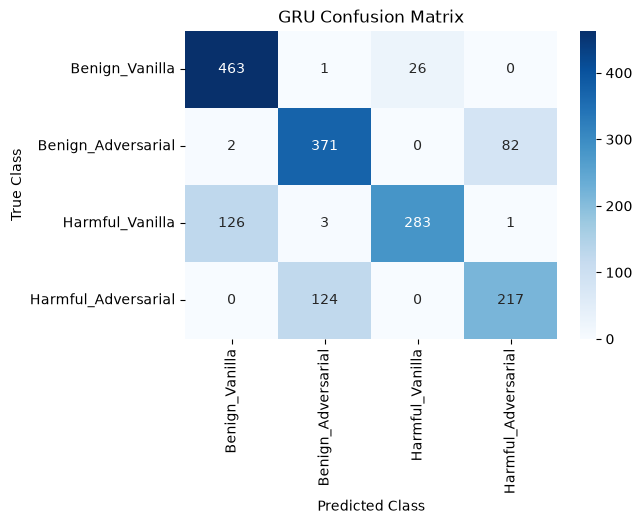


 LSTM Final Test Evaluation
Test Accuracy: 78.58%
Test Macro F1: 0.7765

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.96      0.86       490
 Benign_Adversarial       0.77      0.77      0.77       455
    Harmful_Vanilla       0.92      0.68      0.78       413
Harmful_Adversarial       0.70      0.70      0.70       341

           accuracy                           0.79      1699
          macro avg       0.79      0.77      0.78      1699
       weighted avg       0.79      0.79      0.78      1699



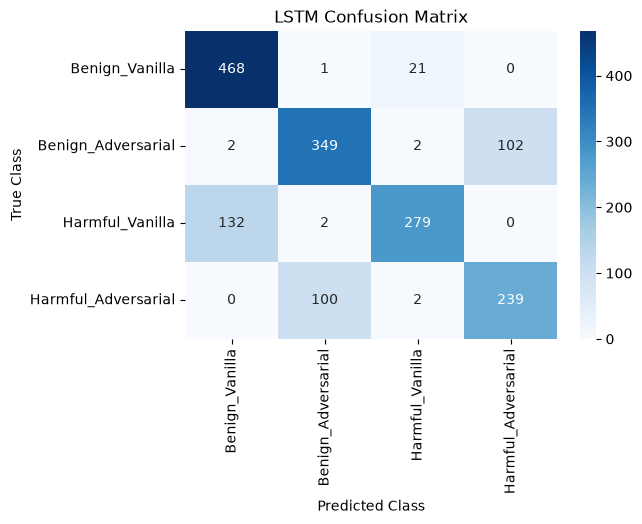


 Bi-SimpleRNN Final Test Evaluation
Test Accuracy: 71.92%
Test Macro F1: 0.7099

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.75      0.91      0.82       490
 Benign_Adversarial       0.74      0.60      0.66       455
    Harmful_Vanilla       0.85      0.63      0.72       413
Harmful_Adversarial       0.57      0.72      0.64       341

           accuracy                           0.72      1699
          macro avg       0.73      0.71      0.71      1699
       weighted avg       0.73      0.72      0.72      1699



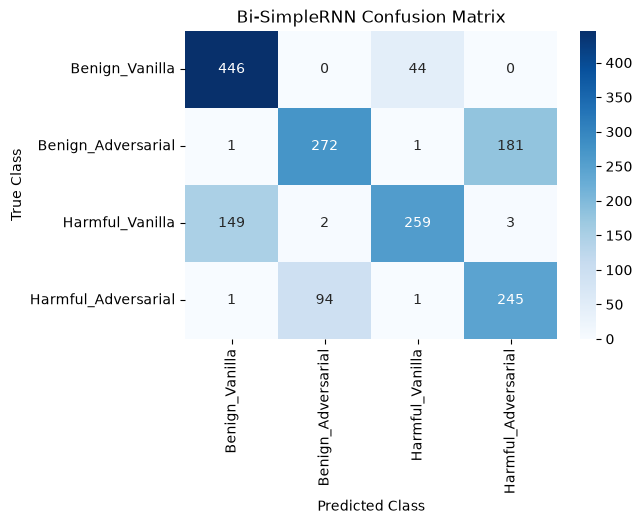


 Bi-GRU Final Test Evaluation
Test Accuracy: 78.75%
Test Macro F1: 0.7783

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.95      0.86       490
 Benign_Adversarial       0.77      0.78      0.77       455
    Harmful_Vanilla       0.91      0.69      0.78       413
Harmful_Adversarial       0.71      0.70      0.70       341

           accuracy                           0.79      1699
          macro avg       0.79      0.78      0.78      1699
       weighted avg       0.80      0.79      0.79      1699



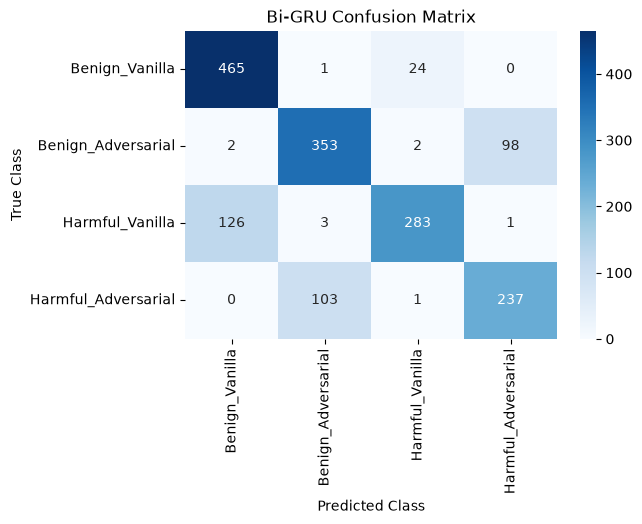


 Bi-LSTM Final Test Evaluation
Test Accuracy: 79.69%
Test Macro F1: 0.7876

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.80      0.94      0.86       490
 Benign_Adversarial       0.76      0.81      0.79       455
    Harmful_Vanilla       0.91      0.71      0.80       413
Harmful_Adversarial       0.73      0.67      0.70       341

           accuracy                           0.80      1699
          macro avg       0.80      0.78      0.79      1699
       weighted avg       0.80      0.80      0.79      1699



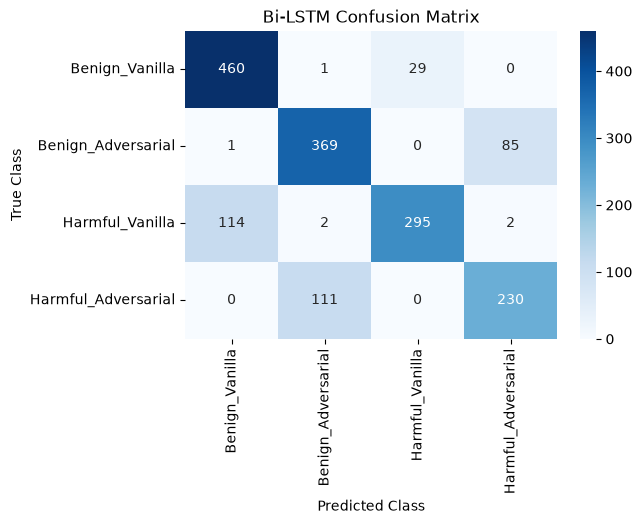


 Final Test Set Comparison (All 10 Models) 


,Model,Test Accuracy,Test Macro F1
0,Random Forest,0.921300,0.915000
1,Logistic Regression,0.896400,0.885000
2,BERT Base,0.855200,0.849000
3,Naive Bayes,0.819200,0.801100
4,Bi-LSTM,0.796939,0.787565
5,Bi-GRU,0.787522,0.778327
6,LSTM,0.785756,0.776459
7,GRU,0.785168,0.773848
8,Bi-SimpleRNN,0.719247,0.709854
9,SimpleRNN,0.660977,0.650888


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import numpy as np
import pandas as pd

test_results = pd.DataFrame(columns=['Model', 'Test Accuracy', 'Test Macro F1'])
class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in best_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")
    
    test_probs = model.predict(X_test_seq, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

test_results.loc[len(test_results)] = ['Naive Bayes', 0.8192, 0.8011]
test_results.loc[len(test_results)] = ['Logistic Regression', 0.8964, 0.8850]
test_results.loc[len(test_results)] = ['Random Forest', 0.9213, 0.9150]
test_results.loc[len(test_results)] = ['BERT Base', 0.8552, 0.8490]

print("\n==========================================")
print(" Final Test Set Comparison (All 10 Models) ")
print("==========================================")
display(test_results.sort_values(by='Test Macro F1', ascending=False).reset_index(drop=True))